# MAPD Project : Clustering - k-Means ||

## Introduction

In this notebook, we implement the k-means‖ algorithm, following the original paper by Bahmani et al., "Scalable K-Means++" (2012). The standard k-means++ initialization is inherently sequential — it selects one center at a time, each depending on the previous ones — which makes it a bottleneck when scaling to large datasets. k-means‖ addresses this by sampling multiple candidate centers in parallel over a small number of rounds, making it suitable for distributed computation.

Our goal is to implement and benchmark this parallelized initialization against the baseline approaches (Random initialization), evaluating both clustering cost and running time. We deploy our implementation on a VM, varying the number of workers and partitions to study its scalability.

The objective of our study is a real-world dataset, KDDCup1999, containing network connection records built for a network intrusion detection challenge. Each record is described by numerical features, and the dataset is large enough (hundreds of thousands to millions of points, depending on the subset used) to be a realistic testbed for the kind of large-k clustering scenario k-means‖ was designed for — unlike small toy datasets, it lets us actually put the parallel initialization to the test at a scale where a sequential approach like k-means++ starts to struggle.




## Initialization algorithm: k-means||

**The k-means‖ algorithm** can be seen as a natural parallelization of k-means++: it keeps the same core idea — repeatedly sampling new candidate centers proportionally to their squared distance from the centers chosen so far ($D^2$-sampling), which is what gives k-means++ its strong theoretical guarantees, but reworks it so that many candidates can be drawn *at once*, instead of one at a time. In k-means++, each new center depends on all the previous ones, center $i+1$ can't be chosen until center $i$ is fixed, so the whole initialization requires $k$ fully sequential passes over the data.

k-means‖ breaks this dependency by oversampling in batches: in each of $r$ rounds, every point $x$ is sampled independently with probability proportional to $\ell \cdot d(x, C)^2 / \phi_X(C)$, where $\ell$ is an oversampling factor and $\phi_X(C)$ is the current clustering cost. All points sampled in a round are added to the candidate set $C$ together. After $r$ rounds, $C$ holds roughly $O(r\ell)$ points — more than the $k$ we actually need. Each candidate is then weighted by how many original data points are closest to it, and this small weighted set is reduced to exactly $k$ centers via a cheap, local weighted k-means++ pass. 

As a baseline, we also test the simplest possible initialization with **Random initialization**: picking $k$ points uniformly at random from the dataset, with no weighting by distance or iterative refinement at all. It's essentially free to compute — a single pass to sample $k$ indices — which makes it a useful lower bound: any more sophisticated initialization (k-means++, k-means‖) should beat it substantially in clustering cost, at the price of extra computation.




## Experimental Set-up

**Experimental setup.** All experiments run on a small cluster of virtual machines connected via SSH: one head node running the scheduler and up to 8 worker nodes, each with roughly 8 GB of RAM. For each run we can choose how many of these workers are active and into how many partitions the dataset is split, and we use exactly these two parameters(number of workers and number of partitions) to sweep the scalability experiments, keeping everything else (dataset size, algorithm parameters) fixed.

**Parallelization with Dask.** We parallelize the algorithm using Dask environment: the dataset is split into partitions with `dask.bag`, and each computation step (sampling, distance updates, Lloyd's assignment) is expressed as a `dask.delayed` task that operates independently on a single partition. These tasks are combined into a task graph and executed with `dask.compute`/`dask.persist`, letting Dask schedule and run them across multiple machines rather than a single process. To actually distribute the work, we launch a `dask.distributed` `SSHCluster` spanning several VM nodes and connect to it via a `Client`; by controlling how many worker nodes join the cluster and how many partitions the data is split into, we can systematically benchmark how the algorithm's running time scales with both parameters.

**SPIEGARE DATA LOAD**


**Data preprocessing / normalization**

Before clustering, `data_loader.load_dataset` drops the non-numeric columns (`protocol_type`, `service`, `flag`) and the `label` column, coerces the rest to numeric, and drops invalid/NaN rows. Global mean and standard deviation are computed for each remaining feature (single pass over the data), constant columns (std=0, e.g. `num_outbound_cmds`) are dropped, and every feature is then standardized to zero mean and unit variance (z-score) before any distance is computed. This reprocessing follows the given suggestion 
to reduce the computational cost, also the running time benefits a lot from it.


## GAUSSIAN mixture 

Firts we start the analysis of the k-means|| algorithm with a smaller syntethic dataset called GaussMixture, where we sampled k centers from a 15-dimensional spherical Gaussian distribution with mean at the origin and variance R. We then added points from Gaussian distributions of unit variance around each center. Given the k centers, this is a mixture of k spherical Gaussians with equal
weights. This is a small dataset with $n=10.000$ sampled points, so we are able to run it on a single machine and to study it with the sequential implementation of k-means||. 

In the figure below, we plot the cost of the final solution as a function of the number of rounds used to initialize k-means|| on GaussMixture with $k=50$ for different values of $R\in \{1,10,100\}$.

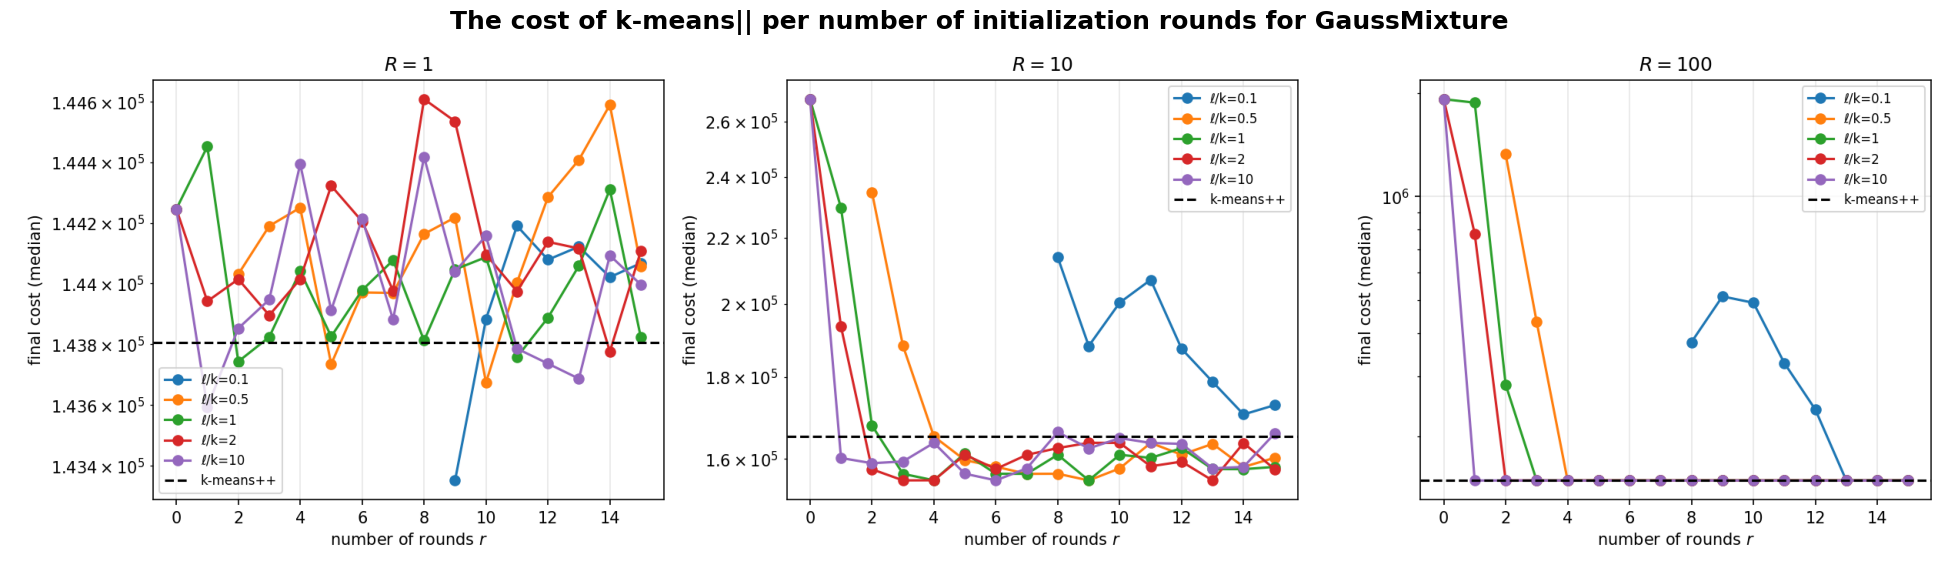

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/home/ubuntu/Project/libero_development/notebooks/figures/fig52_cost_vs_rounds.png")
plt.figure(figsize=(25, 10))
plt.imshow(img)
plt.axis("off")
plt.title("The cost of k-means|| per number of initialization rounds for GaussMixture")
plt.show()


We also plotted the final potential achieved by k-means++ as point of comparison. $R$ is the variance of the Gaussian distribution from which the $k$ cluster centers are drawn (centers ~ $\mathcal{N}(0, R))$ in the GaussMixture synthetic dataset, controlling how well-separated the underlying clusters are: larger $R$ yields more widely dispersed, more distinguishable clusters.


Observe that when $r\cdot l \leq k$, the solution is substantially worse than that of k-means++, as $R$ increases. This is not surprising since in expectation k-means|| has selected too few points. However as soon as $r\cdot l \geq k$, the algorithm finds as good of an initial set as that found by k-means++ and reaches a plateau. 


To evaluate the clustering cost of k-means||, we compare it against the baseline approaches k-means++ and Random ($r=0$), and we compare their cost to that of k-means|| for moderate values of $k=50$

In [19]:
import pandas as pd
from IPython.display import display

# Path to the fig52 CSV already produced by run_fig52 (adjust if needed)
df52 = pd.read_csv("/home/ubuntu/Project/libero_development/results/final_csv/fig52_final.csv")

# Random baseline: r=0 collapses to uniform random centers regardless of l,
# so dedupe across l_over_k to avoid counting the same run 5x in the median
random_rows = (df52[(df52["method"] == "kmeans||") & (df52["r"] == 0)]
               .drop_duplicates(subset=["R", "run"]))

masks = {
    "Random":                 random_rows,
    "k-means++":              df52[df52["method"] == "k-means++"],
    "k-means||, l=k/2, r=5":  df52[(df52["method"] == "kmeans||") &
                                    (df52["l_over_k"] == 0.5) & (df52["r"] == 5)],
    "k-means||, l=2k, r=5":   df52[(df52["method"] == "kmeans||") &
                                    (df52["l_over_k"] == 2) & (df52["r"] == 5)],
}

long_rows = []
for label, sub in masks.items():
    g = (sub.groupby("R")[["cost_seed", "cost_final"]].median() / 1e4).reset_index()
    g["method"] = label
    long_rows.append(g)
long_df = pd.concat(long_rows, ignore_index=True)

table1 = long_df.pivot(index="method", columns="R", values=["cost_seed", "cost_final"])
table1 = table1.swaplevel(axis=1).sort_index(axis=1, level=0)  # colonne: (R, metric)
table1 = table1.reindex(["Random", "k-means++", "k-means||, l=k/2, r=5", "k-means||, l=2k, r=5"])
Rs = sorted(long_df["R"].unique())
ordered_cols = pd.MultiIndex.from_tuples(
    [(r, m) for r in Rs for m in ["cost_seed", "cost_final"]]
)
table1 = table1.reindex(columns=ordered_cols)

display(
    table1.style
    .format("{:.0f}", na_rep="—")
)

The median cost (over 11 runs) on GaussMixture with $k = 50$, scaled down by $10^4$ for $R\in \{1,10,100\}$. We show
both the cost after the initialization step (seed) and the final cost after Lloyd’s iterations (final). It's cleat that k-means++ and k-means|| outperform Random algorithm. For small dataset like this, the k-means|| implementation is comparable with the original k-means++ and there are not significant differences that privileges one algorithm over the other.

## 10 % of KDDCup1999

Before using the entire KDDCup1999 dataset, we started with some exploration, in order to capture the general trend, and test the implementation of our program on the VM. We analyze first about 10% of the dataset so we will have a baseline to compare with the results obtained from the entire dataset. 

First we are interested in the parameters $\ell$ and $k$. The number of clusters $k$ is a property of the problem, so we fix it at two representative large values, $k \in \{500, 1000\}$, matching the regime the paper targets with KDDCup1999. The oversampling factor $\ell$ is instead a tuning parameter of the algorithm: larger $\ell$ means more candidate centers sampled per round, a bigger pool to recluster from, and — in principle — a better initialization, at the cost of more work.

We sweep $\ell$ as a multiple of $k$, with $\ell/k \in \{0.1, 0.5, 1, 2, 5,10,20,100\}$, keeping the number of rounds fixed ($r = 5$, with the adaptive rule bumping $\ell/k = 0.1$ up to 15 rounds so that its candidate pool is not too small). For each $(k, \ell/k)$ pair we run the full pipeline $11$ times with different seeds and look at two quantities: the **final clustering cost** after Lloyd's iterations, and the **total running time**. The plots below report the mean over runs, with error bars for the run-to-run spread. The simulation is made with **8** worker and a total of **64** partitions.





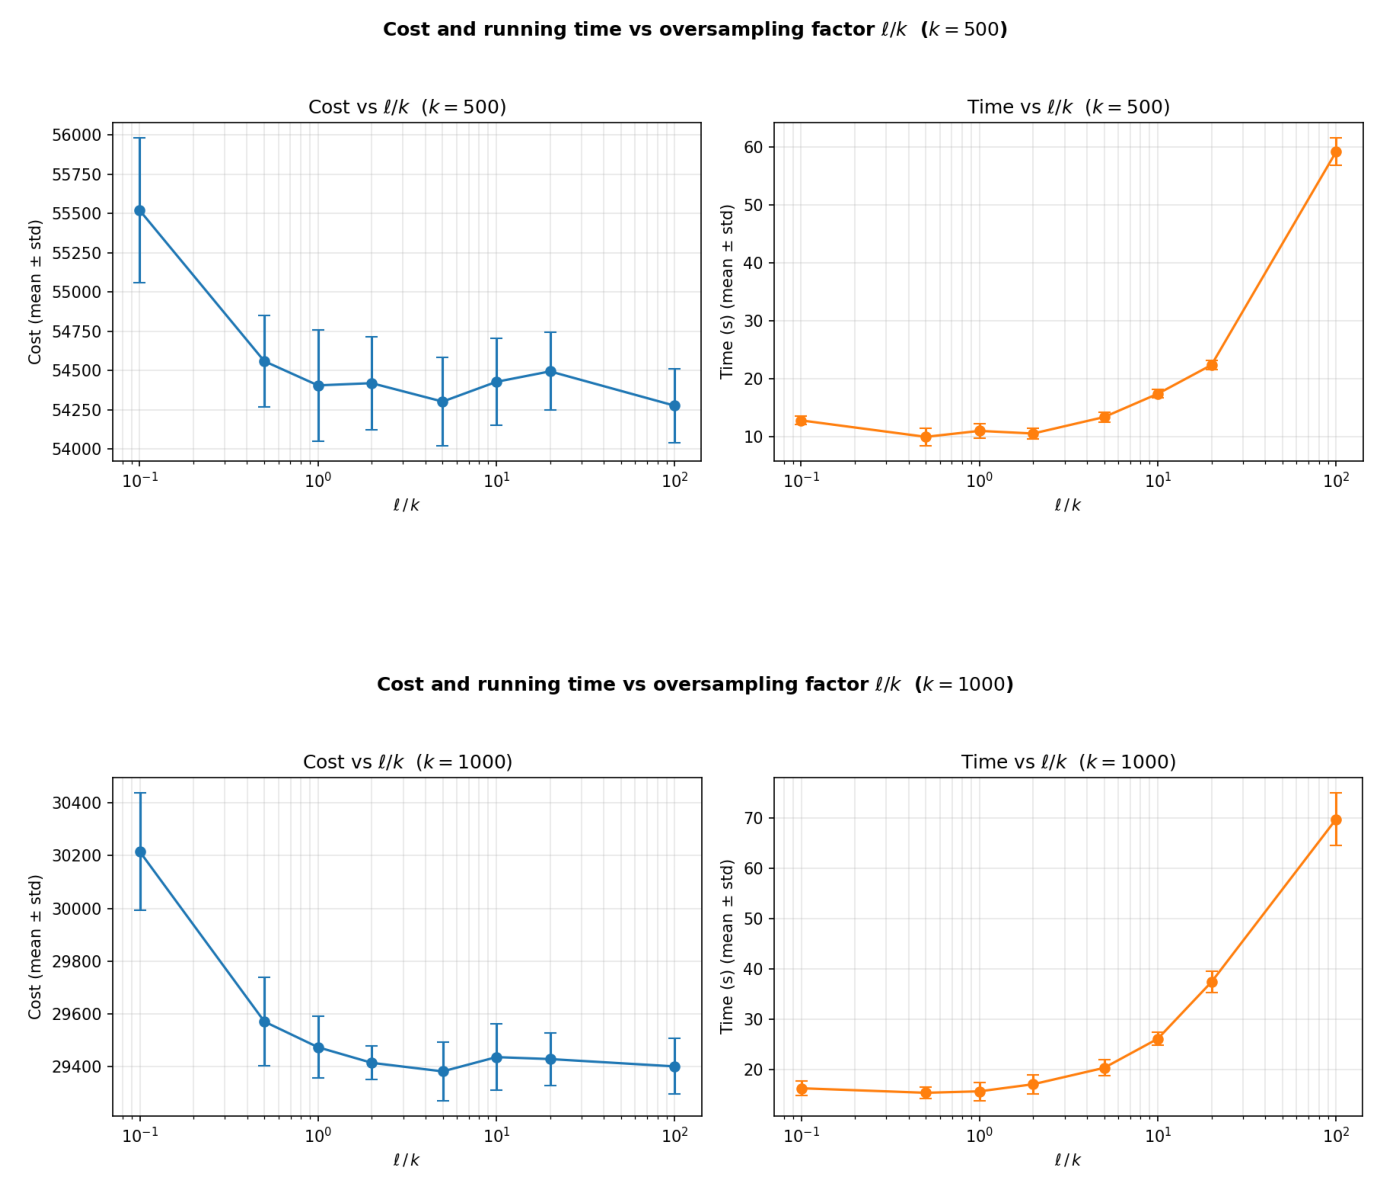

In [3]:
fig1_path = "/home/ubuntu/Project/libero_development/notebooks/figures/l_sweep_k500.png"
fig2_path = "/home/ubuntu/Project/libero_development/notebooks/figures/l_sweep_k1000.png"

img1 = mpimg.imread(fig1_path)
img2 = mpimg.imread(fig2_path)

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()

From the figures we see that the cost monotonically decreases with higher values of $\ell/k$, and that's reasonable since a larger pool covers better the data and leaves the final reclustering room to select the $k$ best representatives rather than being forced to keep every candidate. This is more visible in the cost curves: the final cost drops sharply from $\ell/k = 0.1$ and then starts flatter out beyond $\ell/k \approx 1$, where the pool is already large enough to almost surely contain a good $k$-subset and extra oversampling are no longer needed. 

The running time, unlike the cost, is not monotonic in $\ell/k$: it is highest at $\ell/k = 0.1$ (dominated by the $3\times$ larger round count from the adaptive rule), dips to a minimum around $\ell/k \approx 0.5$–$1$, where $r$ is fixed at $5$ and the extra sampled points are cheap relative to the per-round distributed pass, and then climbs steadily from $\ell/k \geq 5$ onward — by $\ell/k = 100$ it is roughly $5$–$6\times$ the minimum. This growth is not driven by Lloyd's: at large $\ell/k$ the candidate pool is already so rich that the seeding alone nearly matches the final cost ($\text{cost\_seed} \approx \text{cost\_final}$), and Lloyd's converges in a single iteration. The extra time instead comes entirely from the initialization step itself — collecting more sampled points per round and running the client-side weighted k-means++ reclustering over a much larger pool. In other words, past $\ell/k \approx 1$–$2$ we are paying an increasing, accelerating time cost for centers that Lloyd's would have reached anyway, with no corresponding gain in final cost.



By changing the number **r** of rounds, instead k-means|| interpolates between a purely random initialization of k-means and
the biased sequential initialization of k-means++. When $r = 0$ all of the points are sampled uniformly at random,
simulating the Random initialization, and when r = k, the algorithm updates the probability distribution at every step, simulating k-means++

In the next figure show the result on a 10% sample of KDDCup1999, with varying values of k

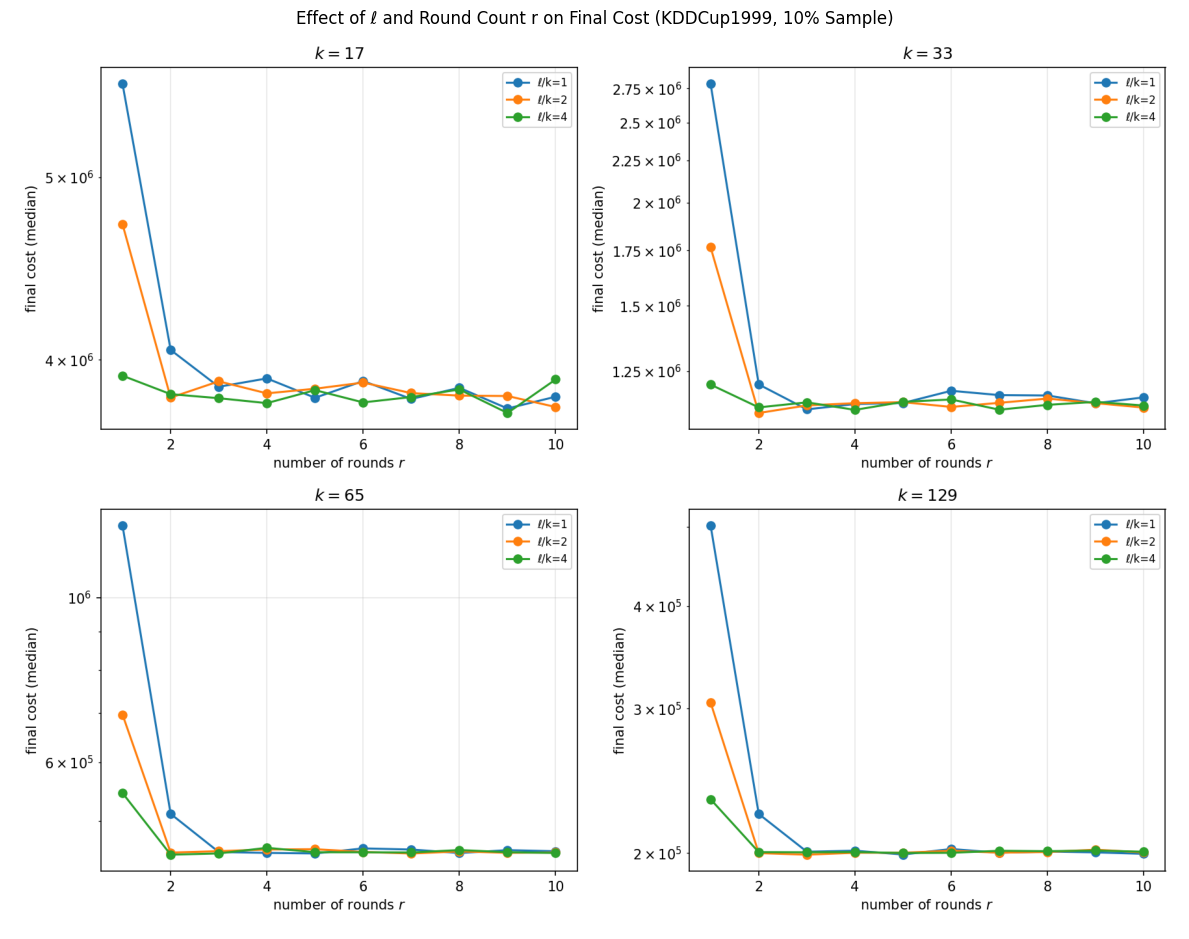

In [4]:
fig1_path = "/home/ubuntu/Project/libero_development/notebooks/figures/fig51_cost_vs_rounds.png"

img1 = mpimg.imread(fig1_path)

fig, axes = plt.subplots(1, 1, figsize=(12, 16))

axes.imshow(img1)
axes.axis("off")
axes.set_title("Effect of ℓ and Round Count r on Final Cost (KDDCup1999, 10% Sample)")


plt.tight_layout()
plt.show()

**Observations**

Across all four panels, the algorithm's final cost falls off sharply between the first and second round of initialization, after which it settles onto a flat, stable plateau that persists through round ten, with only minor run-to-run noise and no further downward trend. At a single round, the three oversampling settings are clearly ordered — larger `l/k` yields a lower cost, since a bigger candidate pool per round produces a better set of points to recluster — but this separation vanishes almost immediately: by the second round, the `l/k=1`, `l/k=2`, and `l/k=4` curves converge and become effectively indistinguishable for the remainder of the sweep. The overall cost level also decreases consistently as `k` grows across panels, which is expected given that more clusters generally reduce total within-cluster distance. Taken together, the plot suggests that for these oversampling factors, essentially all of the achievable improvement is captured within the first two rounds, with additional rounds or a higher `l/k` yielding no meaningful further gain.

Our curves converge much faster than in the original figure: cost drops steeply from `r=1` to `r=2`, then the three `l/k` curves collapse onto a flat plateau. This is expected here, since `l/k∈{1,2,4}` already gives `l≥k` candidates in expectation per round — a single round is enough to fill the pool. Absolute cost is ~10⁵-10⁷ vs. ~10¹⁰-10¹⁶ in the paper for the same 10% KDD sample, most likely due to our feature standardization (not applied/disclosed in the paper). Qualitative trend (higher `l/k` → better at low `r`, then convergence) matches; the scale gap remains an open point.



## Grid-search of best architecture

Now we wanto to find the best combinations of number of workers and partitions, that reduce the total running time. We compare the running time for kmeans parallel, using different numbers of workers and partitions. We performed a grid search on the values  `n_workers={2, 3, 4, 5, 6, 7, 8}` and `n_partitions={16, 32, 64, 128, 256}` over the entire dataset KDDCup1999.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns

In [26]:
workers_csv_path = "/home/ubuntu/Project/libero_development/results/final_csv/workers_partitions.csv"
df = pd.read_csv(workers_csv_path, usecols=["workers", "partitions", "time"])

df = df.loc[:, ["workers", "partitions", "time"]]# , "k", "l"]]
df["time"] = df["time"] / 60

avg_iters = 10

In [27]:
df_grouped = df.groupby(["workers", "partitions"], as_index=False).agg(
    time_mean=("time", "mean"),
    time_std =("time", "std"))
df_grouped["time_std"] = df_grouped["time_std"] / np.sqrt(avg_iters)
df_grouped.head()

,workers,partitions,time_mean,time_std
0,2,16,4.594229,0.245930
1,2,32,2.355339,0.165675
2,2,64,2.846371,0.139464
3,2,128,2.789636,0.044066
4,2,256,2.874366,0.102688


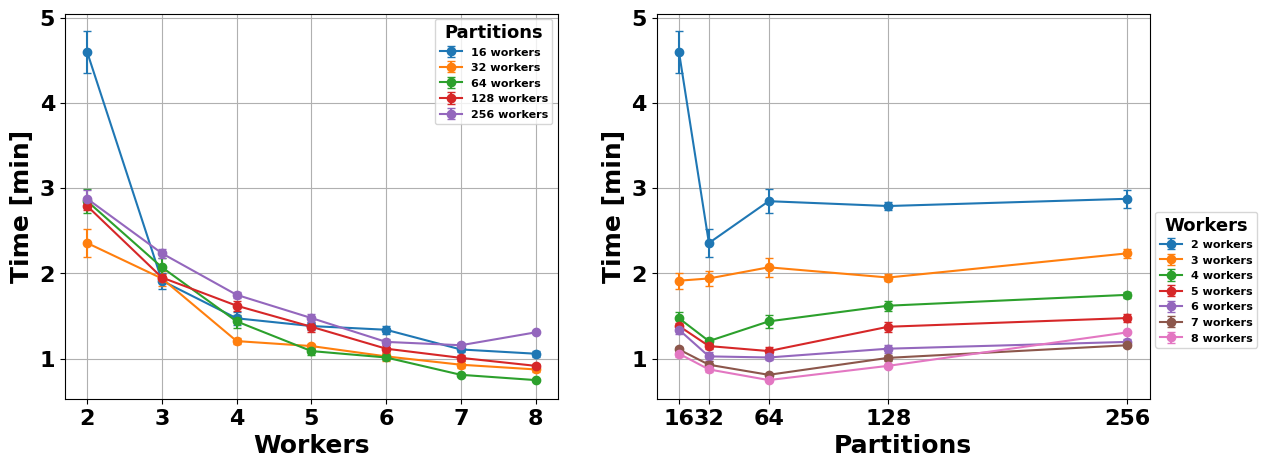

In [28]:
fig, ax = plt.subplots(1, 2, figsize = (14, 5))

for partitions, group in df_grouped.groupby("partitions"):
    ax[0].errorbar(
        group["workers"],
        group["time_mean"],
        yerr=group["time_std"],
        marker="o",
        capsize=3,
        label=f"{partitions} workers"
        )

ax[0].set_xlabel("Workers")
ax[0].set_ylabel("Time [min]")
ax[0].legend(title="Partitions", fontsize=8)
ax[0].grid()


df_grouped = df.groupby(["workers", "partitions"], as_index=False).agg(
    time_mean=("time", "mean"),
    time_std =("time", "std"))
df_grouped["time_std"] = df_grouped["time_std"] / np.sqrt(avg_iters)

for workers, group in df_grouped.groupby("workers"):
    ax[1].errorbar(
        group["partitions"],
        group["time_mean"],
        yerr=group["time_std"],
        marker="o",
        capsize=3,
        label=f"{workers} workers"
    )

ax[1].set_xlabel("Partitions")
ax[1].set_xticks([16, 32, 64, 128, 256])
ax[1].set_ylabel("Time [min]")
ax[1].legend(title="Workers", fontsize=8, bbox_to_anchor=(1, 0.5))
ax[1].grid()

#fig.legend( loc="outside upper right")

From the graph on the left, we notice that the best results are obtained for `n_partitions={32, 64}`, indicating that too many partitions cause a slow probably due to mvoving data in the cluster and not taking advantage of the computation capabilities. More specifically, with less than 4 workers, 32 partitions is the best choice, while for more than 4 workers 64 is the best choice.
The best absolute results are for 8 workers, but having more workers doesn't necessarily imply less comuting time: 7 workers and 256 partitions is slower than 4 workers and 32 partitions for instance.

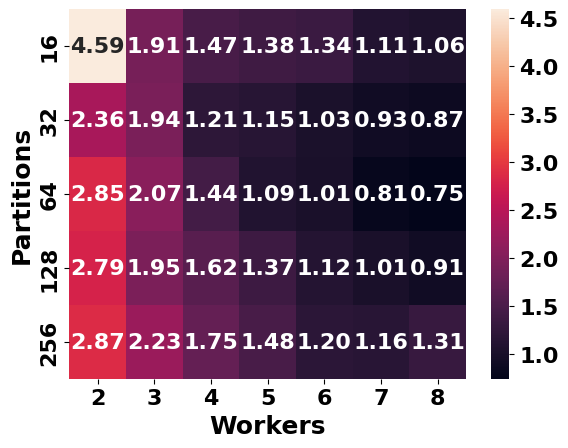

In [25]:
heatmap_data = df_grouped.reset_index().pivot(
    index="partitions",
    columns="workers",
    values="time_mean"
)

sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="rocket")

plt.xlabel("Workers")
plt.ylabel("Partitions")
plt.show()

The heatmap shows that the bes results are achieved for an high number of workers and low partitions

## Results

###  Trading-off quality with running time

Following the format of Table 3 in the original paper, we tested k-means|| with $k \in \{500, 1000\}$ and $\ell \in \{0.1k, 0.5k, k, 2k, 10k\}$, with $r=15 $ rounds for the case $l=0.1k$, and $r=5 $ rounds otherwise: running k-means|| for five rounds when $l=0.1k$ leads it to select fewer than k centers with high probability.  Along with k-means|| we also test Random inizialization. For Random, the parallel implementation is standard3, and works when we select the number of rounds equal to zero $r=0$. In the sequential setting we ran Random until convergence, while in the parallel version, we bounded the number of iterations to 20. 

As in the paper, each value is the **median over 11 random seeds**, to smooth out run-to-run variance.

Table 3 shows the **clustering cost** — the final $k$-means objective after Lloyd's iterations converge. Table 4 shows the **total running time** (initialization + Lloyd's refinement, in minutes), giving a sense of the actual cost of running each configuration in practice.


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

sns.set_palette("tab10")

mpl.rcParams.update({
    # Font
    "font.weight": "bold",
    "font.size": 16,

    # Axes
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 18,
    "axes.labelsize": 18,

    # Tick labels
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Legend
    "legend.fontsize": 16,
    "legend.title_fontsize": 13,

    # Figure title
    "figure.titleweight": "bold",
    "figure.titlesize": 20,

    # Math text (matches regular font)
    "mathtext.default": "bf",
})

In [17]:


# --- edit these paths ---
random_csv = "/home/ubuntu/Project/libero_development/results/final_csv/random_l_su_k_final.csv"
kmeans_csv = "/home/ubuntu/Project/libero_development/results/final_csv/l_su_k_final.csv"


ks = [500, 1000]
ratios = [0.1, 0.5, 1, 2, 10]
ratio_labels = {0.1: "0.1k", 0.5: "0.5k", 1: "k", 2: "2k", 10: "10k"}


def median_by_k(csv_path, value_col):
    df = pd.read_csv(csv_path)
    return df.groupby("k")[value_col].median().to_dict()


def median_by_k_ratio(csv_path, value_col):
    df = pd.read_csv(csv_path)
    return df.groupby(["k", "l_over_k"])[value_col].median().to_dict()


def sigfig(x, n=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{n}g}"


def build_table(value_col, unit_scale=1.0, sig=3):
    random_med = median_by_k(random_csv, value_col)
    kmeans_med = median_by_k_ratio(kmeans_csv, value_col)

    index = [("Random", "")]
    index += [(r"k-means||, l=", ratio_labels[r]) for r in ratios]

    rows = []
    rows.append([sigfig(random_med.get(k, np.nan) * unit_scale, sig) for k in ks])
    for r in ratios:
        rows.append([sigfig(kmeans_med.get((k, r), np.nan) * unit_scale, sig) for k in ks])

    return pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(index), columns=[f"k={k}" for k in ks])


table3_cost = build_table("final_cost")
table4_time = build_table("time", unit_scale=1 / 60)

print("Table 3 - clustering cost")
display(table3_cost)

print("Table 4 - running time (minutes)")
display(table4_time)


Table 3 - clustering cost


k=500    k=1000
Random              3.63e+07  2.48e+07
k-means||, l= 0.1k  5.85e+05  3.14e+05
              0.5k  5.76e+05  3.09e+05
              k      5.7e+05  3.08e+05
              2k    5.71e+05  3.07e+05
              10k   5.72e+05  3.08e+05

Table 4 - running time (minutes)


k=500 k=1000
Random              0.831    1.2
k-means||, l= 0.1k  0.829   1.11
              0.5k  0.719   1.06
              k     0.752   1.09
              2k     0.87   1.26
              10k    1.32   2.28

The results confirm the paper's headline finding: k-means‖ crushes Random initialization by nearly two orders of magnitude in clustering cost (e.g. ~3.6×10⁷ vs ~5.7×10⁵ for k=500), even though both eventually run the same Lloyd's refinement — a much better starting point really does matter.

Where our results diverge a bit from the paper is in the effect of ℓ. The paper reports cost improving monotonically as ℓ grows, up to ℓ=10k. In our runs, the cost drops sharply from ℓ=0.1k to ℓ=k, but then essentially **plateaus** — the differences between ℓ=k, ℓ=2k and ℓ=10k are within noise across seeds, with no clear further improvement. This suggests that, at least for our setup, ℓ=k already captures most of the achievable initialization quality, and oversampling further gives diminishing returns.

That plateau matters because the running time tells the opposite story: time grows with ℓ, and the jump to ℓ=10k is steep (nearly 1.5–2× slower than ℓ=k). So beyond ℓ=k we're paying significantly more time for essentially no gain in cost — a trade-off worth flagging, since blindly picking the largest ℓ would be the wrong call here.

CONTROLLA QUANTO SCRITTO


## Conclusions